In [51]:
import json
import math
from pathlib import Path
import os
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd


fpath = 'empirical_input'
fruns = 'empirical_runs.json'
INPUT = Path(os.path.join(fpath,fruns))
OUT = Path("empiricial_runs_analysis")
OUT.mkdir(exist_ok=True)
EARTH_RADIUS_KM = 6371.0088

In [52]:
# Some helpers to calculate area of query and other
def bbox_area_km2(bbox):
    """
    [north, south, east, west]
    """
    if not bbox or len(bbox) != 4:
        return np.nan

    north, south, east, west = map(float, bbox)

    return (
        EARTH_RADIUS_KM**2
        * abs(
            math.sin(math.radians(north))
            - math.sin(math.radians(south))
        )
        * math.radians(abs(east - west))
    )


def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def p95(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.95) if len(x) else np.nan


def cv_pct(x):
    """Coefficient of variation [%]."""
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) < 2 or x.mean() == 0:
        return np.nan

    return 100 * x.std(ddof=1) / x.mean()


def summary(df, by, value):
    """
    Extended metrics set.
    """
    return (
        df.groupby(by, dropna=False)[value]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
            p95=p95,
            cv_pct=cv_pct,
        )
        .reset_index()
    )


In [53]:
# load data
payload = json.loads(INPUT.read_text(encoding="utf-8"))
runs = payload.get("runs")

In [54]:
# FLATTEN DATA

run_rows = []
dispatch_rows = []
precheck_source_rows = []

for run_id, run in enumerate(runs, start=1):

    request = run.get("request", {})
    precheck = run.get("coverage_precheck", {})
    dispatch = run.get("dispatch", []) or []
    comparison = run.get("cross_source_comparison", {}) or {}

    # REQUEST GEOMETRY

    bbox = request.get("bounding_box")

    if bbox and len(bbox) == 4:
        north, south, east, west = bbox
        bbox_width_deg = abs(east - west)
        bbox_height_deg = abs(north - south)
        bbox_area_deg2 = bbox_width_deg * bbox_height_deg
        area_km2 = bbox_area_km2(bbox)
    else:
        north = south = east = west = np.nan
        bbox_width_deg = bbox_height_deg = np.nan
        bbox_area_deg2 = area_km2 = np.nan

    # TIME RANGE

    time_from = pd.to_datetime(
        request.get("time_from"),
        errors="coerce"
    )

    time_to = pd.to_datetime(
        request.get("time_to"),
        errors="coerce"
    )

    if pd.notna(time_from) and pd.notna(time_to):
        # inclusive, np. Jan 1 -- Jan 7 = 7
        duration_days = (time_to - time_from).days + 1
    else:
        duration_days = np.nan

    # SOURCE TIMINGS

    source_times = [
        x["wall_seconds"]
        for x in dispatch
        if x.get("wall_seconds") is not None
    ]

    dispatch_sum = sum(source_times) if source_times else np.nan
    dispatch_max = max(source_times) if source_times else np.nan

    request_wall = run.get("request_wall_seconds", np.nan)

    # PRECHECK
    
    precheck_seconds = precheck.get("precheck_seconds", np.nan)
    candidate_sources = precheck.get("candidate_sources", np.nan)
    dispatched_sources = precheck.get("dispatched_sources", np.nan)
    requests_avoided = precheck.get("requests_avoided", np.nan)

    # OUTPUT

    cells = run.get("returned_cell_count", np.nan)
    rows = run.get("returned_row_count", np.nan)
    non_null = run.get("non_null_value_count", np.nan)

    factors = request.get("factors", []) or []

    # ONE ROW PER COMPLETE REQUEST

    run_rows.append({

        "run_id": run_id,

        "run_kind": run.get("run_kind"),
        "status": run.get("status"),
        "repeat": run.get("repeat"),
        "comparison_ready": comparison.get("comparison_ready"),
        "overlapping_observation_keys": comparison.get(
            "overlapping_observation_keys", np.nan
        ),
        "required_sources": " | ".join(
            comparison.get("required_sources", [])
        ),
        "observed_sources": " | ".join(
            comparison.get("observed_sources", [])
        ),
        "missing_sources": " | ".join(
            comparison.get("missing_sources", [])
        ),

        "scenario": request.get("scenario"),
        "country": request.get("country"),

        "dimension": request.get("dimension"),
        "input_value": request.get("input_value"),

        "level": request.get("level"),

        "factor_count_requested": len(factors),
        "factors_requested": " | ".join(factors),

        "time_from": time_from,
        "time_to": time_to,
        "duration_days": duration_days,

        # geometry
        "bbox_width_deg": bbox_width_deg,
        "bbox_height_deg": bbox_height_deg,
        "bbox_area_deg2": bbox_area_deg2,
        "bbox_area_km2": area_km2,

        # total request time
        "request_wall_seconds": request_wall,

        # coverage precheck
        "precheck_seconds": precheck_seconds,
        "precheck_microseconds":
            precheck_seconds * 1e6
            if pd.notna(precheck_seconds)
            else np.nan,

        "candidate_sources": candidate_sources,
        "planned_dispatched_sources": dispatched_sources,
        "recorded_dispatch_count": len(dispatch),
        "requests_avoided": requests_avoided,

        # rejected fraction
        "avoidance_fraction":
            safe_div(requests_avoided, candidate_sources),

        "dispatch_fraction":
            safe_div(dispatched_sources, candidate_sources),

        # precheck cost
        "precheck_overhead_pct":
            100 * safe_div(
                precheck_seconds,
                request_wall
            ),

        # average check cost
        "precheck_us_per_candidate":
            1e6 * safe_div(
                precheck_seconds,
                candidate_sources
            ),

        # data_read success rate
        "dispatch_recording_gap":
            (
                dispatched_sources - len(dispatch)
                if pd.notna(dispatched_sources)
                else np.nan
            ),

        # PARALLELISM / OVERHEAD

        "dispatch_sum_seconds": dispatch_sum,
        "dispatch_max_seconds": dispatch_max,

        # slowest source
        "critical_path_share":
            safe_div(dispatch_max, request_wall),

        # ~= orchestration + merging + transformations itd.
        "orchestration_overhead_seconds":
            (
                request_wall - dispatch_max
                if pd.notna(dispatch_max)
                else np.nan
            ),

        "orchestration_overhead_pct":
            (
                100 * safe_div(
                    request_wall - dispatch_max,
                    request_wall
                )
                if pd.notna(dispatch_max)
                else np.nan
            ),


        "parallelism_factor":
            safe_div(dispatch_sum, dispatch_max),

        # RESULT SIZE

        "returned_cell_count": cells,
        "returned_row_count": rows,
        "returned_column_count":
            run.get("returned_column_count", np.nan),

        "returned_factor_count":
            run.get("returned_factor_count", np.nan),

        "non_null_value_count": non_null,

        "quality_report_count":
            run.get("quality_report_count", np.nan),

        "peak_memory_mb":
            run.get("peak_traced_memory_mb", np.nan),

        # THROUGHPUT


        "cells_per_second":
            safe_div(cells, request_wall),

        "rows_per_second":
            safe_div(rows, request_wall),

        "non_null_values_per_second":
            safe_div(non_null, request_wall),

        "seconds_per_1000_cells":
            1000 * safe_div(request_wall, cells),

        "seconds_per_million_values":
            1_000_000 * safe_div(request_wall, non_null),
    })

    # ONE ROW PER ACTUAL SOURCE REQUEST

    for d in dispatch:

        source = d.get("source")

        dispatch_rows.append({

            "run_id": run_id,

            "scenario": request.get("scenario"),
            "run_kind": run.get("run_kind"),
            "repeat": run.get("repeat"),

            "country": request.get("country"),

            "dimension": request.get("dimension"),
            "input_value": request.get("input_value"),

            "level": request.get("level"),

            "bbox_area_km2": area_km2,
            "bbox_area_deg2": bbox_area_deg2,

            "duration_days": duration_days,
            "factor_count_requested": len(factors),

            "source": source,

            "source_short":
                source.split(".")[-1]
                if source
                else None,

            "source_status": d.get("status"),
            "source_wall_seconds": d.get("wall_seconds"),

            "error": d.get("error"),
        })

    # ONE ROW PER SOURCE CONSIDERED BY PRECHECK

    for source_info in precheck.get("sources", []) or []:

        factor_overlap = source_info.get(
            "factor_overlap", []
        ) or []

        precheck_source_rows.append({

            "run_id": run_id,
            "scenario": request.get("scenario"),
            "repeat": run.get("repeat"),

            "source": source_info.get("source"),

            "source_short":
                source_info
                .get("source", "")
                .split(".")[-1],

            "dispatched":
                bool(source_info.get("dispatched")),

            "factor_overlap_count":
                len(factor_overlap),

            "spatial_overlap":
                bool(source_info.get("spatial_overlap")),

            "temporal_overlap":
                bool(source_info.get("temporal_overlap")),

            "disabled":
                source_info.get("disabled_reason")
                is not None,

            "disabled_reason":
                source_info.get("disabled_reason"),
        })


runs_df = pd.DataFrame(run_rows)
dispatch_df = pd.DataFrame(dispatch_rows)
precheck_sources_df = pd.DataFrame(precheck_source_rows)

In [55]:
runs_df

,run_id,run_kind,status,repeat,comparison_ready,overlapping_observation_keys,required_sources,observed_sources,missing_sources,scenario,...,returned_column_count,returned_factor_count,non_null_value_count,quality_report_count,peak_memory_mb,cells_per_second,rows_per_second,non_null_values_per_second,seconds_per_1000_cells,seconds_per_million_values
0,1,coverage,success,1,None,NaN,,,,germany-meteo-overlap,...,74.0,4.0,518.0,2.0,75.945200,0.633170,0.126634,9.370915,1579.354894,1.067132e+05
1,2,coverage,success,1,None,NaN,,,,austria-meteo-overlap,...,88.0,4.0,616.0,2.0,8.023504,1.464526,0.250041,22.003604,682.814983,4.544710e+04
2,3,coverage,success,1,None,NaN,,,,ireland-precipitation-overlap,...,144.0,2.0,1008.0,2.0,22.686952,2.480165,0.144676,20.833382,403.199057,4.799989e+04
3,4,coverage,success,1,None,NaN,,,,ireland-groundwater,...,1.0,1.0,90.0,1.0,79.231113,0.159560,14.360356,14.360356,6267.254300,6.963616e+04
4,5,coverage,success,1,None,NaN,,,,germany-land-cover,...,83.0,1.0,30378.0,1.0,46.734224,4.238150,18.688712,1551.163067,235.951982,6.446775e+02
5,6,coverage,no-data,1,None,NaN,,,,germany-soil,...,NaN,NaN,NaN,NaN,2.230402,NaN,NaN,NaN,NaN,NaN
6,7,coverage,no-data,1,None,NaN,,,,no-spatial-coverage,...,NaN,NaN,NaN,NaN,1.430918,NaN,NaN,NaN,NaN,NaN
7,8,coverage,no-data,1,None,NaN,,,,no-temporal-coverage,...,NaN,NaN,NaN,NaN,0.012425,NaN,NaN,NaN,NaN,NaN
8,9,cross-source,success,1,True,124.0,,DWD | ERA5,,cross-source-germany-meteo,...,74.0,4.0,2294.0,2.0,22.151195,0.322616,0.285745,21.145143,3099.664849,4.729218e+04
9,10,cross-source,success,1,True,186.0,,ERA5 | GeoSphere,,cross-source-austria-meteo,...,88.0,4.0,2728.0,2.0,5.171338,0.826612,0.625000,54.999962,1209.756934,1.818183e+04


In [56]:
dispatch_df

,run_id,scenario,run_kind,repeat,country,dimension,input_value,level,bbox_area_km2,bbox_area_deg2,duration_days,factor_count_requested,source,source_short,source_status,source_wall_seconds,error
0,1,germany-meteo-overlap,coverage,1,Germany,None,NaN,10,7781.036216,1.0,7,2,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,success,15.001459,None
1,1,germany-meteo-overlap,coverage,1,Germany,None,NaN,10,7781.036216,1.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,40.177276,None
2,2,austria-meteo-overlap,coverage,1,Austria,None,NaN,10,8273.257240,1.0,7,2,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,success,2.198899,None
3,2,austria-meteo-overlap,coverage,1,Austria,None,NaN,10,8273.257240,1.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,25.678031,None
4,3,ireland-precipitation-overlap,coverage,1,Ireland,None,NaN,10,7354.501319,1.0,7,1,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,35.169160,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,58,live-s2-level-8,live-scaling,1,Germany,S2 level,8.0,8,7781.036216,1.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,34.585791,None
121,59,live-bbox-width-2.0,live-scaling,1,Germany,Bounding-box area,4.0,10,31122.959752,4.0,7,2,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,success,24.251838,None
122,59,live-bbox-width-2.0,live-scaling,1,Germany,Bounding-box area,4.0,10,31122.959752,4.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,25.017219,None
123,60,live-factor-count-1,live-scaling,3,Germany,Factor count,1.0,10,7781.036216,1.0,7,1,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,success,6.803155,None


In [57]:
precheck_sources_df

,run_id,scenario,repeat,source,source_short,dispatched,factor_overlap_count,spatial_overlap,temporal_overlap,disabled,disabled_reason
0,1,germany-meteo-overlap,1,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,False,2,False,True,False,None
1,1,germany-meteo-overlap,1,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,True,2,True,True,False,None
2,1,germany-meteo-overlap,1,farmwise_api.adapters.API_readers.soilgrids.so...,soilgrids_call,False,0,True,True,False,None
3,1,germany-meteo-overlap,1,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,True,2,True,True,False,None
4,1,germany-meteo-overlap,1,farmwise_api.adapters.API_readers.cds.cds_vege...,cds_vegetation,False,0,True,True,True,The CDS sis-agroproductivity-indicators datase...
...,...,...,...,...,...,...,...,...,...,...,...
1135,60,live-factor-count-1,3,farmwise_api.adapters.API_readers.irish_meteo....,Irish MS_daily,False,0,False,True,False,None
1136,60,live-factor-count-1,3,farmwise_api.adapters.API_readers.hubeau.hubea...,hubeau_sw_quality_read,False,0,True,True,False,None
1137,60,live-factor-count-1,3,farmwise_api.adapters.API_readers.EuroCropV2.E...,EuroCropV2_read,False,0,True,True,False,None
1138,60,live-factor-count-1,3,farmwise_api.adapters.API_readers.IFSGRID.IFSG...,IFSGRID_read,False,0,True,False,True,The current upstream IFSGRID archive does not ...


In [58]:
# 1. TIME PER SOURCE
per_source = (
    dispatch_df
    .groupby(["source", "source_short"])
    .agg(
        n=("source_wall_seconds", "count"),

        mean_seconds=("source_wall_seconds", "mean"),
        median_seconds=("source_wall_seconds", "median"),
        std_seconds=("source_wall_seconds", "std"),

        p95_seconds=("source_wall_seconds", p95),

        min_seconds=("source_wall_seconds", "min"),
        max_seconds=("source_wall_seconds", "max"),

        success_rate=(
            "source_status",
            lambda x: (x == "success").mean()
        ),

        timeout_rate=(
            "source_status",
            lambda x: (x == "timeout").mean()
        ),

        failure_rate=(
            "source_status",
            lambda x: (x == "failure").mean()
        ),
    )
    .reset_index()
    .sort_values("mean_seconds", ascending=False)
)


In [59]:
per_source

,source,source_short,n,mean_seconds,median_seconds,std_seconds,p95_seconds,min_seconds,max_seconds,success_rate,timeout_rate,failure_rate
1,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,55,40.681156,34.728304,27.142614,107.658588,16.577891,148.167461,1.000000,0.0,0.000000
7,farmwise_api.adapters.API_readers.soilgrids.so...,soilgrids_call,6,36.157111,32.152279,10.125281,50.409521,25.526471,52.424219,0.833333,0.0,0.166667
6,farmwise_api.adapters.API_readers.irish_meteo....,Irish MS_daily,2,28.659541,28.659541,21.906181,42.600549,13.169532,44.149550,1.000000,0.0,0.000000
8,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,50,10.145843,7.442867,11.770292,25.645378,1.735606,82.772165,1.000000,0.0,0.000000
0,farmwise_api.adapters.API_readers.EuroCropV2.E...,EuroCropV2_read,4,8.483199,8.048656,1.966221,10.783091,6.593084,11.242402,0.000000,0.0,0.000000
2,farmwise_api.adapters.API_readers.corine.corin...,corine_read,4,8.097777,7.937200,1.062267,9.308911,7.029728,9.486978,1.000000,0.0,0.000000
3,farmwise_api.adapters.API_readers.epa_ireland....,epa_gw,1,6.249268,6.249268,NaN,6.249268,6.249268,6.249268,1.000000,0.0,0.000000
5,farmwise_api.adapters.API_readers.imgw.imgw_ap...,imgw_api_synop_daily,1,3.289066,3.289066,NaN,3.289066,3.289066,3.289066,1.000000,0.0,0.000000
4,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,2,2.301302,2.301302,0.144819,2.393464,2.198899,2.403704,1.000000,0.0,0.000000


In [60]:
# 2. per query times
per_query = summary(
    runs_df,
    [
        "scenario",
        "dimension",
        "input_value",
        "level",
        "country",
    ],
    "request_wall_seconds"
)
per_query

,scenario,dimension,input_value,level,country,n,mean,median,std,min,max,p95,cv_pct
0,austria-meteo-overlap,NaN,NaN,10,Austria,1,27.995414,27.995414,NaN,27.995414,27.995414,27.995414,NaN
1,cross-source-austria-meteo,NaN,NaN,10,Austria,1,49.600034,49.600034,NaN,49.600034,49.600034,49.600034,NaN
2,cross-source-germany-meteo,NaN,NaN,10,Germany,1,108.488270,108.488270,NaN,108.488270,108.488270,108.488270,NaN
3,cross-source-ireland-precipitation,NaN,NaN,10,Ireland,1,86.911842,86.911842,NaN,86.911842,86.911842,86.911842,NaN
4,cross-source-poland-imgw-era5,NaN,NaN,10,Poland,1,70.640503,70.640503,NaN,70.640503,70.640503,70.640503,NaN
5,germany-land-cover,NaN,NaN,10,Germany,1,19.584015,19.584015,NaN,19.584015,19.584015,19.584015,NaN
6,germany-meteo-overlap,NaN,NaN,10,Germany,1,55.277421,55.277421,NaN,55.277421,55.277421,55.277421,NaN
7,germany-soil,NaN,NaN,10,Germany,1,30.880140,30.880140,NaN,30.880140,30.880140,30.880140,NaN
8,ireland-groundwater,NaN,NaN,10,Ireland,1,6.267254,6.267254,NaN,6.267254,6.267254,6.267254,NaN
9,ireland-precipitation-overlap,NaN,NaN,10,Ireland,1,48.383887,48.383887,NaN,48.383887,48.383887,48.383887,NaN


In [61]:
# 3. Level scaling test
s2 = runs_df[
    runs_df["dimension"] == "S2 level"
].copy()

per_level = summary(
    s2,
    ["level"],
    "request_wall_seconds"
)

level_extra = (
    s2.groupby("level")
    .agg(
        cells_mean=("returned_cell_count", "mean"),
        memory_mean_mb=("peak_memory_mb", "mean"),
        values_mean = ('non_null_value_count','mean'),
        values_per_second_mean=(
            "non_null_values_per_second",
            "mean"
        )
    )
    .reset_index()
)

per_level = per_level.merge(
    level_extra,
    on="level"
)
per_level

,level,n,mean,median,std,min,max,p95,cv_pct,cells_mean,memory_mean_mb,values_mean,values_per_second_mean
0,6,3,53.559021,42.194656,27.803257,33.238135,85.244271,80.939309,51.911437,4.0,21.854739,56.0,1.222977
1,8,3,45.930272,41.361806,14.061410,34.721170,61.707841,59.673238,30.614690,13.0,21.881000,182.0,4.197112
2,10,3,47.498754,35.742464,21.179550,34.804996,71.948802,68.328168,44.589697,35.0,21.852349,490.0,11.532674
3,12,3,36.098943,35.088756,9.260875,27.384577,45.823497,44.750023,25.654145,37.0,21.908453,518.0,14.994188


In [62]:
level_extra

,level,cells_mean,memory_mean_mb,values_mean,values_per_second_mean
0,6,4.0,21.854739,56.0,1.222977
1,8,13.0,21.881000,182.0,4.197112
2,10,35.0,21.852349,490.0,11.532674
3,12,37.0,21.908453,518.0,14.994188


In [63]:
# 4. BOUNDING BOX / QUERY AREA SCALING

area_runs = runs_df[
    runs_df["dimension"] == "Bounding-box area"
].copy()

per_area = summary(
    area_runs,
    [
        "input_value",
        "bbox_area_deg2",
        "bbox_area_km2",
    ],
    "request_wall_seconds"
)

area_extra = (
    area_runs
    .groupby(
        [
            "input_value",
            "bbox_area_deg2",
            "bbox_area_km2"
        ]
    )
    .agg(
        cells_mean=("returned_cell_count", "mean"),

        memory_mean_mb=(
            "peak_memory_mb",
            "mean"
        ),
                values_mean = ('non_null_value_count','mean'),
        cells_per_second_mean=(
            "cells_per_second",
            "mean"
        ),
    )
    .reset_index()
)

per_area = per_area.merge(
    area_extra,
    on=[
        "input_value",
        "bbox_area_deg2",
        "bbox_area_km2",
    ]
)

area_extra

,input_value,bbox_area_deg2,bbox_area_km2,cells_mean,memory_mean_mb,values_mean,cells_per_second_mean
0,0.0625,0.0625,486.320550,2.0,9.733900,28.0,0.067608
1,0.2500,0.2500,1945.277572,10.0,11.728671,140.0,0.401323
2,1.0000,1.0000,7781.036216,35.0,21.852688,490.0,1.009018
3,4.0000,4.0000,31122.959752,126.0,24.609242,1764.0,2.213635


In [64]:
per_area

,input_value,bbox_area_deg2,bbox_area_km2,n,mean,median,std,min,max,p95,cv_pct,cells_mean,memory_mean_mb,values_mean,cells_per_second_mean
0,0.0625,0.0625,486.320550,3,30.285353,27.789749,5.923666,26.017832,37.048478,36.122605,19.559507,2.0,9.733900,28.0,0.067608
1,0.2500,0.2500,1945.277572,3,25.768922,28.779448,5.380115,19.557473,28.969845,28.950805,20.878307,10.0,11.728671,140.0,0.401323
2,1.0000,1.0000,7781.036216,3,35.866109,31.709116,8.468052,30.279915,45.609295,44.219277,23.610179,35.0,21.852688,490.0,1.009018
3,4.0000,4.0000,31122.959752,3,57.464061,58.013166,6.784235,50.421960,63.957057,63.362668,11.806049,126.0,24.609242,1764.0,2.213635


In [65]:
# 5. NUMBER OF FACTORS SCALING


factor_runs = runs_df[
    runs_df["dimension"] == "Factor count"
].copy()

per_factor_count = summary(
    factor_runs,
    ["factor_count_requested"],
    "request_wall_seconds"
)

factor_extra = (
    factor_runs
    .groupby("factor_count_requested")
    .agg(
        returned_factors_mean=(
            "returned_factor_count",
            "mean"
        ),

        columns_mean=(
            "returned_column_count",
            "mean"
        ),

        memory_mean_mb=(
            "peak_memory_mb",
            "mean"
        ),

        values_per_second_mean=(
            "non_null_values_per_second",
            "mean"
        ),
    )
    .reset_index()
)

per_factor_count = per_factor_count.merge(
    factor_extra,
    on="factor_count_requested"
)

factor_extra

,factor_count_requested,returned_factors_mean,columns_mean,memory_mean_mb,values_per_second_mean
0,1,1.000000,35.0,21.853659,5.967606
1,2,2.000000,70.0,21.852790,10.332379
2,3,9.333333,972.0,21.882383,89.302751
3,4,14.000000,1506.0,46.159032,94.146488


In [66]:
per_factor_count

,factor_count_requested,n,mean,median,std,min,max,p95,cv_pct,returned_factors_mean,columns_mean,memory_mean_mb,values_per_second_mean
0,1,3,41.380982,43.883129,4.359384,36.347227,43.912589,43.909643,10.534753,1.000000,35.0,21.853659,5.967606
1,2,3,61.810943,43.841304,41.878464,31.916143,109.675382,103.091975,67.752508,2.000000,70.0,21.852790,10.332379
2,3,3,73.009328,69.027152,11.433635,64.099283,85.901550,84.214110,15.660512,9.333333,972.0,21.882383,89.302751
3,4,3,114.066210,122.272691,18.080210,93.338162,126.587778,126.156270,15.850627,14.000000,1506.0,46.159032,94.146488


In [67]:
# 6. REQUEST DURATION SCALING

duration_runs = runs_df[
    runs_df["dimension"] == "Requested days"
].copy()

per_duration = summary(
    duration_runs,
    ["duration_days"],
    "request_wall_seconds"
)

duration_extra = (
    duration_runs
    .groupby("duration_days")
    .agg(
        rows_mean=("returned_row_count", "mean"),
        cells_mean=("returned_cell_count", "mean"),
        columns_mean=("returned_column_count", "mean"),
        memory_mean_mb=("peak_memory_mb", "mean"),
        values_mean=("non_null_value_count", "mean"),
        values_per_second_mean=(
            "non_null_values_per_second",
            "mean"
        ),
    )
    .reset_index()
)

per_duration = per_duration.merge(
    duration_extra,
    on="duration_days"
)

per_duration

,duration_days,n,mean,median,std,min,max,p95,cv_pct,rows_mean,cells_mean,columns_mean,memory_mean_mb,values_mean,values_per_second_mean
0,1,3,41.873915,43.851710,4.726402,36.479894,45.290142,45.146299,11.287222,1.0,35.0,70.0,21.853497,70.0,1.686915
1,7,3,42.446607,33.745100,15.461332,33.296783,60.297939,57.642655,36.425365,7.0,35.0,70.0,21.910814,490.0,12.454359
2,30,3,42.127147,44.544350,5.015210,36.361114,45.475976,45.382813,11.904936,30.0,35.0,70.0,21.881491,2100.0,50.358754
3,90,3,147.280120,141.149995,17.666065,133.495671,167.194694,164.590224,11.994874,90.0,35.0,70.0,21.879980,6300.0,43.168845


In [68]:
# 6. SOURCE TIME PER LEVEL
source_by_level = summary(
    dispatch_df,
    ["source_short", "level"],
    "source_wall_seconds"
)

source_by_level

,source_short,level,n,mean,median,std,min,max,p95,cv_pct
0,EuroCropV2_read,10,4,8.483199,8.048656,1.966221,6.593084,11.242402,10.783091,23.177819
1,Irish MS_daily,10,2,28.659541,28.659541,21.906181,13.169532,44.149550,42.600549,76.435910
2,cds_single_levels,6,3,45.814832,34.991046,28.402376,24.415735,78.037716,73.733049,61.993845
3,cds_single_levels,8,3,38.178915,34.585791,14.666404,25.642980,54.307975,52.335757,38.414930
4,cds_single_levels,10,46,41.336185,34.892446,28.664684,16.577891,148.167461,118.169434,69.345257
5,cds_single_levels,12,3,28.005942,27.480440,9.080492,19.199612,37.337773,36.352039,32.423448
6,corine_read,10,4,8.097777,7.937200,1.062267,7.029728,9.486978,9.308911,13.118007
7,epa_gw,10,1,6.249268,6.249268,NaN,6.249268,6.249268,6.249268,NaN
8,geosphere,10,2,2.301302,2.301302,0.144819,2.198899,2.403704,2.393464,6.292932
9,imgw_api_synop_daily,10,1,3.289066,3.289066,NaN,3.289066,3.289066,3.289066,NaN


In [69]:
# 7. SOURCE TIME PER QUERY AREA

source_by_area = summary(
    dispatch_df[
        dispatch_df["dimension"] == "Bounding-box area"
    ],
    [
        "source_short",
        "input_value",
        "bbox_area_km2",
    ],
    "source_wall_seconds"
)
source_by_area

,source_short,input_value,bbox_area_km2,n,mean,median,std,min,max,p95,cv_pct
0,cds_single_levels,0.0625,486.320550,3,28.283241,25.909346,5.645734,24.212072,34.728304,33.846408,19.961412
1,cds_single_levels,0.2500,1945.277572,3,22.952601,26.104986,5.520771,16.577891,26.174926,26.167932,24.052923
2,cds_single_levels,1.0000,7781.036216,3,28.533799,24.291416,8.369643,23.134847,38.175134,36.786762,29.332382
3,cds_single_levels,4.0000,31122.959752,3,30.239115,29.686634,5.518915,25.017219,36.013491,35.380806,18.250916
4,wetterdienst_dwd,0.0625,486.320550,3,1.922631,1.753542,0.308534,1.735606,2.278745,2.226225,16.047497
5,wetterdienst_dwd,0.2500,1945.277572,3,2.614743,2.649334,0.114931,2.486490,2.708405,2.702498,4.395487
6,wetterdienst_dwd,1.0000,7781.036216,3,6.909398,6.991433,0.159624,6.725438,7.011322,7.009333,2.310241
7,wetterdienst_dwd,4.0000,31122.959752,3,25.956047,26.785547,1.476061,24.251838,26.830756,26.826235,5.686772


In [70]:
# 8. SOURCE TIME PER FACTOR COUNT

source_by_factor_count = summary(
    dispatch_df[
        dispatch_df["dimension"] == "Factor count"
    ],
    [
        "source_short",
        "factor_count_requested",
    ],
    "source_wall_seconds"
)
source_by_factor_count

,source_short,factor_count_requested,n,mean,median,std,min,max,p95,cv_pct
0,EuroCropV2_read,4,3,7.563465,7.916977,0.850629,6.593084,8.180334,8.153998,11.246548
1,cds_single_levels,1,3,33.916403,36.535811,4.890940,28.273650,36.939749,36.899355,14.420573
2,cds_single_levels,2,3,28.977191,26.487416,6.845516,23.725013,36.719143,35.695970,23.623807
3,cds_single_levels,3,3,25.079529,25.253935,1.223338,23.778349,26.206305,26.111068,4.877835
4,cds_single_levels,4,3,44.060241,37.331220,11.731405,37.243098,57.606405,55.578887,26.625830
5,corine_read,4,3,8.030413,7.574532,1.290499,7.029728,9.486978,9.295733,16.070152
6,soilgrids_call,3,3,35.326988,31.293544,7.842577,30.321993,44.365427,43.058239,22.199959
7,soilgrids_call,4,3,36.987234,33.011013,13.882722,25.526471,52.424219,50.482898,37.533819
8,wetterdienst_dwd,1,3,7.251396,7.183226,0.485925,6.803155,7.767805,7.709347,6.701119
9,wetterdienst_dwd,2,3,32.380182,7.677845,43.643530,6.690535,82.772165,75.262733,134.784697


In [71]:
# 9. COVERAGE PRECHECK

precheck_summary = pd.DataFrame([{

    "mean_us":
        runs_df["precheck_microseconds"].mean(),

    "median_us":
        runs_df["precheck_microseconds"].median(),

    "p95_us":
        p95(runs_df["precheck_microseconds"]),

    "max_us":
        runs_df["precheck_microseconds"].max(),

    "mean_overhead_pct":
        runs_df["precheck_overhead_pct"].mean(),

    "mean_candidates":
        runs_df["candidate_sources"].mean(),

    "mean_dispatched":
        runs_df["planned_dispatched_sources"].mean(),

    "mean_requests_avoided":
        runs_df["requests_avoided"].mean(),

    "mean_avoidance_fraction":
        runs_df["avoidance_fraction"].mean(),

    "mean_us_per_candidate":
        runs_df["precheck_us_per_candidate"].mean(),
}])
precheck_summary

,mean_us,median_us,p95_us,max_us,mean_overhead_pct,mean_candidates,mean_dispatched,mean_requests_avoided,mean_avoidance_fraction,mean_us_per_candidate
0,208.881667,193.849999,377.045002,424.3,0.13782,19.0,2.116667,16.883333,0.888596,10.993772


In [72]:
# 10. WHY SOURCES ARE REJECTED

precheck_by_source = (
    precheck_sources_df
    .groupby(["source", "source_short"])
    .agg(
        considered=("run_id", "count"),

        dispatched=(
            "dispatched",
            "sum"
        ),

        disabled=(
            "disabled",
            "sum"
        ),

        no_factor_overlap=(
            "factor_overlap_count",
            lambda x: (x == 0).sum()
        ),

        no_spatial_overlap=(
            "spatial_overlap",
            lambda x: (~x).sum()
        ),

        no_temporal_overlap=(
            "temporal_overlap",
            lambda x: (~x).sum()
        ),
    )
    .reset_index()
)

precheck_by_source["dispatch_rate"] = (
    precheck_by_source["dispatched"]
    / precheck_by_source["considered"]
)
precheck_by_source

,source,source_short,considered,dispatched,disabled,no_factor_overlap,no_spatial_overlap,no_temporal_overlap,dispatch_rate
0,farmwise_api.adapters.API_readers.EuroCropV2.E...,EuroCropV2_read,60,4,0,56,0,1,0.066667
1,farmwise_api.adapters.API_readers.IFSGRID.IFSG...,IFSGRID_read,60,0,60,56,0,56,0.000000
2,farmwise_api.adapters.API_readers.UA_sw_qualit...,ukrainian_surface_water,60,0,0,60,60,0,0.000000
3,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,60,55,0,5,0,0,0.916667
4,farmwise_api.adapters.API_readers.cds.cds_vege...,cds_vegetation,60,0,60,59,0,4,0.000000
5,farmwise_api.adapters.API_readers.corine.corin...,corine_read,60,4,0,56,0,0,0.066667
6,farmwise_api.adapters.API_readers.eea.eea_read,eea_read,60,0,0,60,0,0,0.000000
7,farmwise_api.adapters.API_readers.epa_ireland....,epa_gw,60,1,0,58,57,0,0.016667
8,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,60,2,0,5,58,0,0.033333
9,farmwise_api.adapters.API_readers.gios.gios_sc...,gios_scraper,60,0,0,53,59,1,0.000000


In [73]:
# 11. REPEATABILITY / NOISE

live = runs_df[
    runs_df["run_kind"] == "live-scaling"
]

repeat_stability = (
    live.groupby(
        [
            "scenario",
            "dimension",
            "input_value",
        ]
    )
    .agg(
        repeats=("repeat", "nunique"),

        request_mean_seconds=(
            "request_wall_seconds",
            "mean"
        ),

        request_std_seconds=(
            "request_wall_seconds",
            "std"
        ),

        request_cv_pct=(
            "request_wall_seconds",
            cv_pct
        ),

        request_min_seconds=(
            "request_wall_seconds",
            "min"
        ),

        request_max_seconds=(
            "request_wall_seconds",
            "max"
        ),

        memory_mean_mb=(
            "peak_memory_mb",
            "mean"
        ),

        memory_cv_pct=(
            "peak_memory_mb",
            cv_pct
        ),
    )
    .reset_index()
    .sort_values(
        "request_cv_pct",
        ascending=False
    )
)
repeat_stability

,scenario,dimension,input_value,repeats,request_mean_seconds,request_std_seconds,request_cv_pct,request_min_seconds,request_max_seconds,memory_mean_mb,memory_cv_pct
9,live-factor-count-2,Factor count,2.0000,3,61.810943,41.878464,67.752508,31.916143,109.675382,21.852790,0.001195
14,live-s2-level-6,S2 level,6.0000,3,53.559021,27.803257,51.911437,33.238135,85.244271,21.854739,0.001583
12,live-s2-level-10,S2 level,10.0000,3,47.498754,21.179550,44.589697,34.804996,71.948802,21.852349,0.002164
6,live-duration-days-7,Requested days,7.0000,3,42.446607,15.461332,36.425365,33.296783,60.297939,21.910814,0.235550
15,live-s2-level-8,S2 level,8.0000,3,45.930272,14.061410,30.614690,34.721170,61.707841,21.881000,0.227121
13,live-s2-level-12,S2 level,12.0000,3,36.098943,9.260875,25.654145,27.384577,45.823497,21.908453,0.220884
2,live-bbox-width-1.0,Bounding-box area,1.0000,3,35.866109,8.468052,23.610179,30.279915,45.609295,21.852688,0.002140
1,live-bbox-width-0.5,Bounding-box area,0.2500,3,25.768922,5.380115,20.878307,19.557473,28.969845,11.728671,0.404400
0,live-bbox-width-0.25,Bounding-box area,0.0625,3,30.285353,5.923666,19.559507,26.017832,37.048478,9.733900,0.011809
11,live-factor-count-4,Factor count,4.0000,3,114.066210,18.080210,15.850627,93.338162,126.587778,46.159032,0.095944


# Cross-source

In [74]:
fpath = 'empirical_input'
fcorss = 'cross_source_observations_live.csv'
INPUT = Path(os.path.join(fpath,fcorss))
OUT = Path("observation_overview")
OUT.mkdir(exist_ok=True)
KEY = [
    "scenario",
    "timestamp",
    "cell",
    "variable",
]
df = pd.read_csv(INPUT)
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)
df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

In [75]:
KEY = [
    "scenario",
    "timestamp",
    "cell",
    "variable",
]

n_sources = (
    df.groupby(KEY)["source"]
      .nunique()
      .rename("n_sources")
      .reset_index()
)

duplicated_keys = n_sources[
    n_sources["n_sources"] > 1
]

print("All unique observation keys:", len(n_sources))
print("Keys covered by >1 source:", len(duplicated_keys))
print(
    "Share with cross-source overlap:",
    f"{100 * len(duplicated_keys) / len(n_sources):.3f}%"
)

print("\nNumber of sources per observation:")
print(
    n_sources["n_sources"]
    .value_counts()
    .sort_index()
)

All unique observation keys: 15996
Keys covered by >1 source: 1178
Share with cross-source overlap: 7.364%

Number of sources per observation:
1    14818
2     1178
Name: n_sources, dtype: int64


In [76]:
n_sources.sort_values('n_sources')

,scenario,timestamp,cell,variable,n_sources
0,cross-source-austria-meteo,2018-01-01,CellId: 476c010000000000,precipitation,1
10646,cross-source-poland-imgw-era5,2018-01-10,CellId: 4710970000000000,precipitation,1
10647,cross-source-poland-imgw-era5,2018-01-10,CellId: 4710970000000000,temperature,1
10648,cross-source-poland-imgw-era5,2018-01-10,CellId: 4710a50000000000,precipitation,1
10649,cross-source-poland-imgw-era5,2018-01-10,CellId: 4710a50000000000,temperature,1
...,...,...,...,...,...
6290,cross-source-ireland-precipitation,2018-01-14,CellId: 485c5b0000000000,precipitation,2
14111,cross-source-poland-imgw-era5,2018-01-24,CellId: 47178b0000000000,temperature,2
14110,cross-source-poland-imgw-era5,2018-01-24,CellId: 47178b0000000000,precipitation,2
6279,cross-source-ireland-precipitation,2018-01-14,CellId: 485c370000000000,precipitation,2


In [77]:
overlap = df.merge(
    duplicated_keys[KEY],
    on=KEY,
    how="inner"
)

In [78]:
from itertools import combinations
pair_rows = []

for key_values, same in overlap.groupby(KEY):

    scenario, timestamp, cell, variable = key_values

    # protection against accidental duplicates within one source
    same = (
        same.groupby("source", as_index=False)
            .agg(value=("value", "mean"))
    )

    for (_, a), (_, b) in combinations(
        same.iterrows(),
        2,
    ):

        value_a = a["value"]
        value_b = b["value"]

        if pd.isna(value_a) or pd.isna(value_b):
            continue

        # alphabetical order → stable pair names
        if a["source"] <= b["source"]:
            source_a = a["source"]
            source_b = b["source"]
            va = value_a
            vb = value_b
        else:
            source_a = b["source"]
            source_b = a["source"]
            va = value_b
            vb = value_a

        diff = va - vb

        pair_rows.append({
            "scenario": scenario,
            "timestamp": timestamp,
            "cell": cell,
            "variable": variable,

            "source_a": source_a,
            "source_b": source_b,

            "source_pair":
                f"{source_a} – {source_b}",

            "value_a": va,
            "value_b": vb,

            # signed difference
            "difference": diff,

            # absolute disagreement
            "absolute_difference": abs(diff),

            # midpoint of the two values
            "pair_mean":
                (va + vb) / 2,
        })


pairs = pd.DataFrame(pair_rows)

print("\nPairwise comparisons:", len(pairs))
print("\nPairs:")
print(
    pairs["source_pair"]
    .value_counts()
)


Pairwise comparisons: 1178

Pairs:
ERA5 – Irish MS_daily    744
ERA5 – GeoSphere         186
DWD – ERA5               124
ERA5 – IMGW              124
Name: source_pair, dtype: int64


In [79]:
def rmse(x):
    return np.sqrt(np.mean(x ** 2))


summary = (
    pairs
    .groupby(
        [
            "scenario",
            "variable",
            "source_pair",
        ]
    )
    .agg(
        n=("difference", "size"),

        # systematic difference: A - B
        mean_bias=("difference", "mean"),
        median_bias=("difference", "median"),

        # magnitude of disagreement
        mae=("absolute_difference", "mean"),
        median_absolute_difference=(
            "absolute_difference",
            "median"
        ),

        p90_absolute_difference=(
            "absolute_difference",
            lambda x: x.quantile(0.90)
        ),

        p95_absolute_difference=(
            "absolute_difference",
            lambda x: x.quantile(0.95)
        ),

        max_absolute_difference=(
            "absolute_difference",
            "max"
        ),

        rmse=(
            "difference",
            rmse
        ),
    )
    .reset_index()
)

summary

,scenario,variable,source_pair,n,mean_bias,median_bias,mae,median_absolute_difference,p90_absolute_difference,p95_absolute_difference,max_absolute_difference,rmse
0,cross-source-austria-meteo,precipitation,ERA5 – GeoSphere,93,0.446758,0.093937,1.042486,0.556614,2.895832,3.288111,5.019182,1.607941
1,cross-source-austria-meteo,temperature,ERA5 – GeoSphere,93,-1.087836,-0.921472,1.207804,0.921472,2.643338,2.976354,3.845192,1.527142
2,cross-source-germany-meteo,precipitation,DWD – ERA5,62,-0.172414,-0.044227,1.427807,0.791960,4.009576,4.660953,6.266917,2.103853
3,cross-source-germany-meteo,temperature,DWD – ERA5,62,-0.319565,-0.054681,1.293927,1.285693,1.976613,2.225393,2.465298,1.421630
4,cross-source-ireland-precipitation,precipitation,ERA5 – Irish MS_daily,744,-1.115396,-0.393231,3.928550,3.328843,8.135346,11.625322,23.049079,5.367649
5,cross-source-poland-imgw-era5,precipitation,ERA5 – IMGW,62,0.568646,0.195980,0.755355,0.466626,1.823547,2.437173,5.812431,1.224681
6,cross-source-poland-imgw-era5,temperature,ERA5 – IMGW,62,0.193891,0.163689,0.467428,0.324963,1.066445,1.188017,1.581073,0.605937


In [80]:
# Add correlation separately
correlations = []

for keys, same in pairs.groupby(
    [
        "scenario",
        "variable",
        "source_pair",
    ]
):
    scenario, variable, source_pair = keys

    if (
        len(same) >= 2
        and same["value_a"].std() > 0
        and same["value_b"].std() > 0
    ):
        r = same[
            ["value_a", "value_b"]
        ].corr().iloc[0, 1]

    else:
        r = np.nan

    correlations.append({
        "scenario": scenario,
        "variable": variable,
        "source_pair": source_pair,
        "pearson_r": r,
    })


correlations = pd.DataFrame(correlations)
correlations

,scenario,variable,source_pair,pearson_r
0,cross-source-austria-meteo,precipitation,ERA5 – GeoSphere,0.700180
1,cross-source-austria-meteo,temperature,ERA5 – GeoSphere,0.939515
2,cross-source-germany-meteo,precipitation,DWD – ERA5,0.866657
3,cross-source-germany-meteo,temperature,DWD – ERA5,0.881180
4,cross-source-ireland-precipitation,precipitation,ERA5 – Irish MS_daily,0.291120
5,cross-source-poland-imgw-era5,precipitation,ERA5 – IMGW,0.770365
6,cross-source-poland-imgw-era5,temperature,ERA5 – IMGW,0.987130


In [81]:
summary = summary.merge(
    correlations,
    on=[
        "scenario",
        "variable",
        "source_pair",
    ],
    how="left"
)
summary

,scenario,variable,source_pair,n,mean_bias,median_bias,mae,median_absolute_difference,p90_absolute_difference,p95_absolute_difference,max_absolute_difference,rmse,pearson_r
0,cross-source-austria-meteo,precipitation,ERA5 – GeoSphere,93,0.446758,0.093937,1.042486,0.556614,2.895832,3.288111,5.019182,1.607941,0.700180
1,cross-source-austria-meteo,temperature,ERA5 – GeoSphere,93,-1.087836,-0.921472,1.207804,0.921472,2.643338,2.976354,3.845192,1.527142,0.939515
2,cross-source-germany-meteo,precipitation,DWD – ERA5,62,-0.172414,-0.044227,1.427807,0.791960,4.009576,4.660953,6.266917,2.103853,0.866657
3,cross-source-germany-meteo,temperature,DWD – ERA5,62,-0.319565,-0.054681,1.293927,1.285693,1.976613,2.225393,2.465298,1.421630,0.881180
4,cross-source-ireland-precipitation,precipitation,ERA5 – Irish MS_daily,744,-1.115396,-0.393231,3.928550,3.328843,8.135346,11.625322,23.049079,5.367649,0.291120
5,cross-source-poland-imgw-era5,precipitation,ERA5 – IMGW,62,0.568646,0.195980,0.755355,0.466626,1.823547,2.437173,5.812431,1.224681,0.770365
6,cross-source-poland-imgw-era5,temperature,ERA5 – IMGW,62,0.193891,0.163689,0.467428,0.324963,1.066445,1.188017,1.581073,0.605937,0.987130


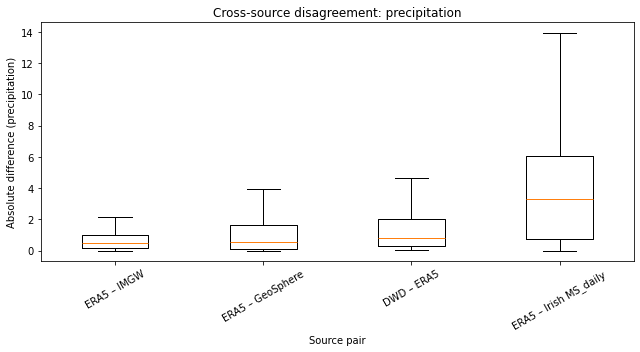

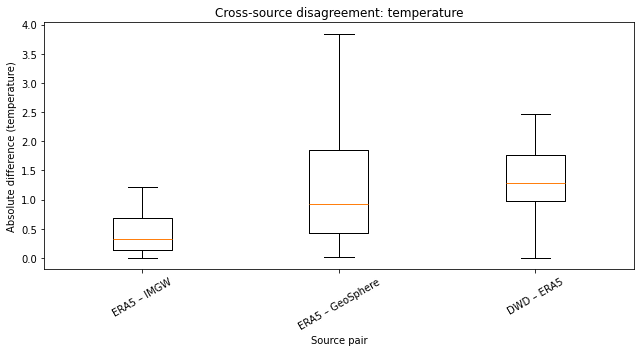

In [82]:
variables = pairs["variable"].unique()

for variable in variables:

    sub = pairs[
        pairs["variable"] == variable
    ].copy()

    pairs_order = (
        sub.groupby("source_pair")["absolute_difference"]
           .median()
           .sort_values()
           .index
    )

    data = [
        sub.loc[
            sub["source_pair"] == pair,
            "absolute_difference"
        ].dropna()
        for pair in pairs_order
    ]
    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.boxplot(
        data,
        showfliers=False
    )
    ax.set_xticks(
        range(1, len(pairs_order) + 1),
        labels=pairs_order,
    )
    ax.set_ylabel(
        f"Absolute difference ({variable})"
    )

    ax.set_xlabel(
        "Source pair"
    )

    ax.set_title(
        f"Cross-source disagreement: {variable}"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    fig.tight_layout()

    fig.savefig(
        f"cross_source_difference_{variable}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

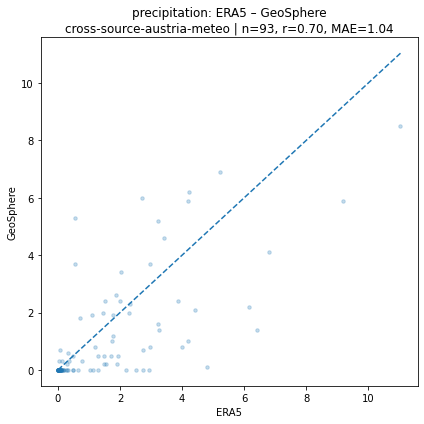

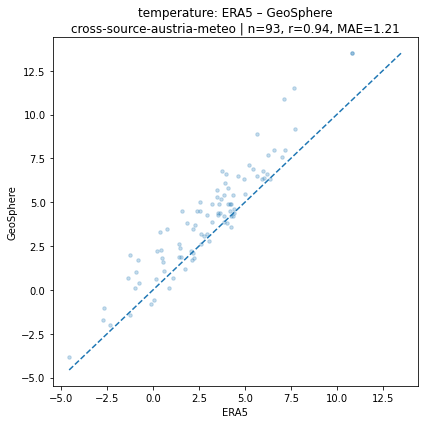

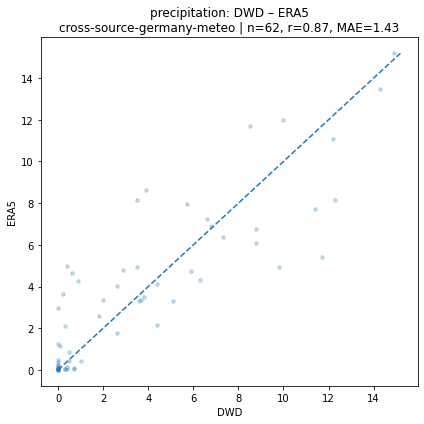

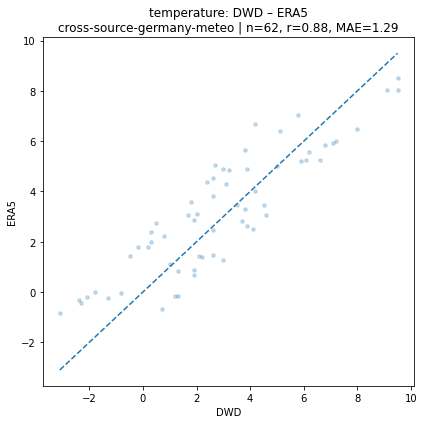

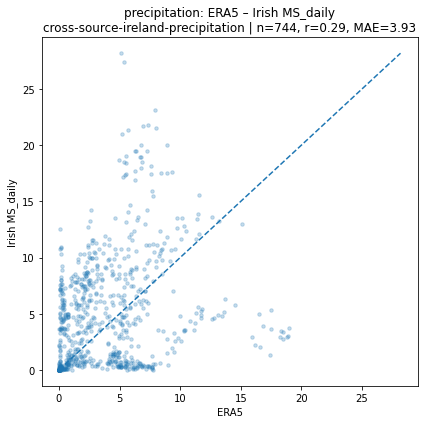

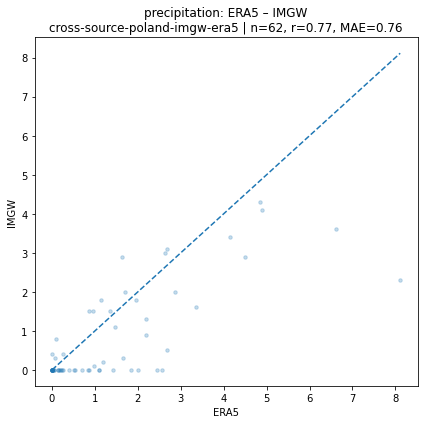

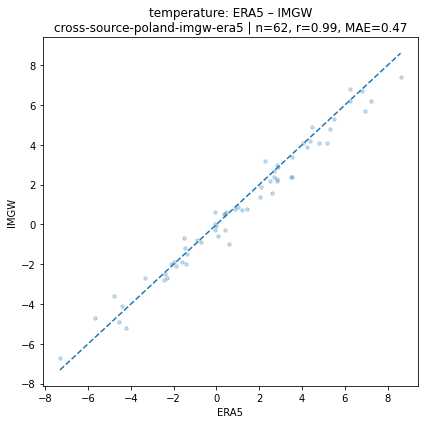

In [83]:
for (
    scenario,
    variable,
    source_pair
), sub in pairs.groupby(
    [
        "scenario",
        "variable",
        "source_pair",
    ]
):

    if len(sub) < 10:
        continue

    fig, ax = plt.subplots(
        figsize=(6, 6)
    )

    ax.scatter(
        sub["value_a"],
        sub["value_b"],
        alpha=0.25,
        s=12
    )

    minimum = min(
        sub["value_a"].min(),
        sub["value_b"].min()
    )

    maximum = max(
        sub["value_a"].max(),
        sub["value_b"].max()
    )

    # perfect agreement line
    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel(
        sub["source_a"].iloc[0]
    )

    ax.set_ylabel(
        sub["source_b"].iloc[0]
    )

    r = sub[
        ["value_a", "value_b"]
    ].corr().iloc[0, 1]

    mae = sub[
        "absolute_difference"
    ].mean()

    ax.set_title(
        f"{variable}: {source_pair}\n"
        f"{scenario} | n={len(sub):,}, "
        f"r={r:.2f}, MAE={mae:.2f}"
    )

    fig.tight_layout()

    plt.show()

In [84]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

QUALITY_DIR = INPUT.parent / payload.get(
    "quality_report_dir",
    "quality",
)
OUT_DIR = Path("quality_summary")

OUT_DIR.mkdir(exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def load_quality_report(path: Path) -> dict:
    """
    Supports:
      - JSON quality reports
      - one-row CSV quality reports

    The attached example is JSON.
    """

    # First try JSON, regardless of extension
    try:
        with path.open("r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, dict):
            return obj

    except (json.JSONDecodeError, UnicodeDecodeError):
        pass


def to_datetime(value):
    return pd.to_datetime(
        value,
        errors="coerce",
    )


def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def weighted_fraction(values, weights):
    """Weighted mean of report-level fractions, bounded to [0, 1]."""
    values = pd.to_numeric(values, errors="coerce").clip(0, 1)
    weights = pd.to_numeric(weights, errors="coerce")
    valid = values.notna() & weights.notna() & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def p05(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.05) if len(x) else np.nan


def p95(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.95) if len(x) else np.nan


def cv_pct(x):
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) < 2 or x.mean() == 0:
        return np.nan

    return (
        100
        * x.std(ddof=1)
        / abs(x.mean())
    )


def summarise_group(group):
    """
    Summarise a set of quality reports.
    """

    result = {
        # number of reports
        "n_reports": len(group),

        # ----------------------------------------------------
        # S2 spatial support (descriptive, not a quality defect)
        # ----------------------------------------------------

        "S2_support_mean":
            group["S2_support_fraction"].mean(),

        "S2_support_median":
            group["S2_support_fraction"].median(),

        "S2_support_std":
            group["S2_support_fraction"].std(),

        "S2_support_p05":
            p05(group["S2_support_fraction"]),

        "S2_support_p95":
            p95(group["S2_support_fraction"]),

        "S2_support_min":
            group["S2_support_fraction"].min(),

        "S2_support_max":
            group["S2_support_fraction"].max(),

        # weighted by expected cells; uses the report-level intersection
        # fraction, so cells outside the request cannot push it above 1
        "S2_support_weighted":
            weighted_fraction(
                group["S2_support_fraction"],
                group["expected_s2_cells"],
            ),

        "expected_s2_cells_total":
            group["expected_s2_cells"].sum(),

        "returned_s2_cells_total":
            group["returned_s2_cells"].sum(),

        "unrepresented_s2_cells_total":
            group["unrepresented_s2_cells"].sum(),

        # ----------------------------------------------------
        # TEMPORAL COMPLETENESS
        # ----------------------------------------------------

        "missing_days_mean":
            group["missing_days"].mean(),

        "missing_days_median":
            group["missing_days"].median(),

        "missing_days_p95":
            p95(group["missing_days"]),

        "missing_days_max":
            group["missing_days"].max(),

        "reports_with_missing_days":
            (group["missing_days"] > 0).sum(),

        "reports_with_missing_days_pct":
            100 * (group["missing_days"] > 0).mean(),

        # independently derived from expected/returned
        # date boundaries
        "start_delay_days_mean":
            group["start_delay_days"].mean(),

        "end_cutshort_days_mean":
            group["end_cutshort_days"].mean(),

        "temporal_span_completeness_mean":
            group["temporal_span_completeness"].mean(),

        "temporal_span_completeness_min":
            group["temporal_span_completeness"].min(),

        # ----------------------------------------------------
        # MISSING VALUES
        # ----------------------------------------------------

        "total_missing_values_mean":
            group["total_missing_values"].mean(),

        "total_missing_values_median":
            group["total_missing_values"].median(),

        "total_missing_values_p95":
            p95(group["total_missing_values"]),

        "total_missing_values_max":
            group["total_missing_values"].max(),

        "reports_with_missing_values":
            (group["total_missing_values"] > 0).sum(),

        "reports_with_missing_values_pct":
            100
            * (group["total_missing_values"] > 0).mean(),

        "factor_missing_values_mean":
            group["factor_missing_values"].mean(),

        # ----------------------------------------------------
        # ERROR / IMPLAUSIBLE VALUES
        # ----------------------------------------------------

        "error_values_mean":
            group["error_values"].mean(),

        "error_values_median":
            group["error_values"].median(),

        "error_values_p95":
            p95(group["error_values"]),

        "error_values_max":
            group["error_values"].max(),

        "reports_with_error_values":
            (group["error_values"] > 0).sum(),

        "reports_with_error_values_pct":
            100
            * (group["error_values"] > 0).mean(),

        # ----------------------------------------------------
        # FACTOR COMPLETENESS
        # ----------------------------------------------------

        "factor_completeness_mean":
            group["factors_returned_completeness"].mean(),

        "factor_completeness_median":
            group["factors_returned_completeness"].median(),

        "factor_completeness_min":
            group["factors_returned_completeness"].min(),

        "factor_completeness_p05":
            p05(group["factors_returned_completeness"]),

        "supported_factors_total":
            group["supported_factor_count"].sum(),

        "returned_output_columns_total":
            group["returned_output_column_count"].sum(),

        # Completeness applies only to requested factors supported by this
        # source. A logical factor such as soil may yield many columns.
        "factor_completeness_weighted":
            weighted_fraction(
                group["factors_returned_completeness"],
                group["supported_factor_count"],
            ),

        "reports_with_incomplete_supported_factors":
            (
                group["factors_returned_completeness"] < 1
            ).sum(),

        "reports_with_incomplete_supported_factors_pct":
            100 * (
                group["factors_returned_completeness"] < 1
            ).mean(),
    }

    return pd.Series(result)


# ============================================================
# READ ALL FILES
# ============================================================

report_rows = []
factor_rows = []

files = [
    p
    for p in QUALITY_DIR.iterdir()
    if p.is_file()
]

print(
    f"Found {len(files):,} quality report files."
)


for path in files:

    try:
        report = load_quality_report(path)

    except Exception as e:
        print(
            f"SKIPPING {path.name}: {e}"
        )
        continue

    # --------------------------------------------------------
    # BASIC VALUES
    # --------------------------------------------------------

    source = report.get("source")

    # fallback to filename if source field is absent
    if not source:
        filename = path.stem

        if "_" in filename:
            source = filename.split(
                "_",
                maxsplit=1,
            )[1]

    level = pd.to_numeric(
        report.get("S2_level"),
        errors="coerce",
    )

    expected_s2 = pd.to_numeric(
        report.get("expected_s2_cells"),
        errors="coerce",
    )

    returned_s2 = pd.to_numeric(
        report.get("returned_s2_cells"),
        errors="coerce",
    )

    s2_support_fraction = pd.to_numeric(
        report.get("S2_completeness"),
        errors="coerce",
    )
    if pd.notna(s2_support_fraction):
        s2_support_fraction = float(
            np.clip(s2_support_fraction, 0, 1)
        )
    represented_s2 = (
        s2_support_fraction * expected_s2
        if pd.notna(s2_support_fraction) and pd.notna(expected_s2)
        else np.nan
    )

    # --------------------------------------------------------
    # DATES
    # --------------------------------------------------------

    expected_start = to_datetime(
        report.get("expected_start")
    )

    expected_end = to_datetime(
        report.get("expected_end")
    )

    returned_start = to_datetime(
        report.get("returned_start")
    )

    returned_end = to_datetime(
        report.get("returned_end")
    )

    if (
        pd.notna(expected_start)
        and pd.notna(expected_end)
    ):
        expected_days = (
            expected_end - expected_start
        ).days + 1
    else:
        expected_days = np.nan

    if (
        pd.notna(returned_start)
        and pd.notna(returned_end)
    ):
        returned_span_days = (
            returned_end - returned_start
        ).days + 1
    else:
        returned_span_days = np.nan

    # delay at beginning
    if (
        pd.notna(expected_start)
        and pd.notna(returned_start)
    ):
        start_delay_days = max(
            0,
            (returned_start - expected_start).days,
        )
    else:
        start_delay_days = np.nan

    # missing end
    if (
        pd.notna(expected_end)
        and pd.notna(returned_end)
    ):
        end_cutshort_days = max(
            0,
            (expected_end - returned_end).days,
        )
    else:
        end_cutshort_days = np.nan

    temporal_span_completeness = (
        safe_div(
            returned_span_days,
            expected_days,
        )
    )

    # cap at 1 in case source gives a slightly larger range
    if pd.notna(temporal_span_completeness):
        temporal_span_completeness = min(
            1.0,
            temporal_span_completeness,
        )

    # --------------------------------------------------------
    # FACTORS
    # --------------------------------------------------------

    factors_expected = (
        report.get("factors_expected", [])
        or []
    )

    factors_returned = (
        report.get("factors_returned", [])
        or []
    )

    supported_factor_count = len(
        factors_expected
    )

    returned_output_column_count = len(
        factors_returned
    )

    supported_factor_completeness = pd.to_numeric(
        report.get("factors_returned_completeness"),
        errors="coerce",
    )
    if pd.notna(supported_factor_completeness):
        supported_factor_completeness = float(
            np.clip(supported_factor_completeness, 0, 1)
        )

    # --------------------------------------------------------
    # REPORT-LEVEL ROW
    # --------------------------------------------------------

    report_rows.append({
        "filename": path.name,

        "request_id":
            report.get("request_id"),

        "created_at":
            to_datetime(
                report.get("created_at")
            ),

        "source":
            source,

        "api_name":
            report.get("api_name"),

        "S2_level":
            level,

        # Spatial support. This is the fraction of requested S2 cells
        # represented by the source, not a missing-data quality score.
        "S2_support_fraction":
            s2_support_fraction,

        "expected_s2_cells":
            expected_s2,

        "returned_s2_cells":
            returned_s2,

        "represented_s2_cells":
            represented_s2,

        "unrepresented_s2_cells":
            (
                max(expected_s2 - represented_s2, 0)
                if (
                    pd.notna(expected_s2)
                    and pd.notna(represented_s2)
                )
                else np.nan
            ),

        # dates
        "expected_start":
            expected_start,

        "expected_end":
            expected_end,

        "returned_start":
            returned_start,

        "returned_end":
            returned_end,

        "expected_days":
            expected_days,

        "returned_span_days":
            returned_span_days,

        "start_delay_days":
            start_delay_days,

        "end_cutshort_days":
            end_cutshort_days,

        "temporal_span_completeness":
            temporal_span_completeness,

        # values supplied directly by report
        "missing_days":
            pd.to_numeric(
                report.get("missing_days"),
                errors="coerce",
            ),

        "data_delay":
            pd.to_numeric(
                report.get("data_delay"),
                errors="coerce",
            ),

        "data_cutshort":
            pd.to_numeric(
                report.get("data_cutshort"),
                errors="coerce",
            ),

        "total_missing_values":
            pd.to_numeric(
                report.get(
                    "total_missing_values"
                ),
                errors="coerce",
            ),

        "factor_missing_values":
            pd.to_numeric(
                report.get(
                    "factor_missing_values"
                ),
                errors="coerce",
            ),

        "error_values":
            pd.to_numeric(
                report.get("error_values"),
                errors="coerce",
            ),

        # factors
        # Only source-supported requested logical factors form the
        # denominator; returned physical columns are reported separately.
        "supported_factor_count":
            supported_factor_count,

        "returned_output_column_count":
            returned_output_column_count,

        "factors_expected":
            " | ".join(
                map(str, factors_expected)
            ),

        "factors_returned":
            " | ".join(
                map(str, factors_returned)
            ),

        "factors_returned_completeness":
            supported_factor_completeness,
    })

    # ========================================================
    # FACTOR-LEVEL QUALITY
    # ========================================================

    missing_rates = (
        report.get(
            "factor_missing_value_rates",
            {}
        )
        or {}
    )

    implausible_rates = (
        report.get(
            "implausible_value_rates",
            {}
        )
        or {}
    )

    factor_names = set(
        missing_rates
    ) | set(
        implausible_rates
    )

    for factor in factor_names:

        factor_rows.append({
            "filename":
                path.name,

            "request_id":
                report.get("request_id"),

            "source":
                source,

            "S2_level":
                level,

            "factor":
                factor,

            "missing_value_rate":
                pd.to_numeric(
                    missing_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),

            "implausible_value_rate":
                pd.to_numeric(
                    implausible_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),
        })


reports_df = pd.DataFrame(report_rows)
factors_df = pd.DataFrame(factor_rows)


# ============================================================
# ADD GENERAL ISSUE FLAG
# ============================================================

reports_df["has_quality_issue"] = (
    (reports_df["missing_days"] > 0)
    | (reports_df["total_missing_values"] > 0)
    | (reports_df["error_values"] > 0)
    | (
        reports_df[
            "factors_returned_completeness"
        ] < 1
    )
)


# ============================================================
# SUMMARY PER SOURCE
# ============================================================

by_source = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
)


# ============================================================
# SUMMARY PER S2 LEVEL
# ============================================================

by_level = (
    reports_df
    .groupby(
        "S2_level",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values("S2_level")
)


# ============================================================
# SUMMARY PER SOURCE × S2 LEVEL
# ============================================================

by_source_level = (
    reports_df
    .groupby(
        [
            "source",
            "S2_level",
        ],
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values(
        [
            "source",
            "S2_level",
        ]
    )
)


# ============================================================
# FACTOR-LEVEL SUMMARY
# ============================================================

if not factors_df.empty:

    by_factor = (
        factors_df
        .groupby(
            [
                "source",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            missing_rate_max=(
                "missing_value_rate",
                "max",
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),

            implausible_rate_max=(
                "implausible_value_rate",
                "max",
            ),
        )
        .reset_index()
    )

    by_factor_level = (
        factors_df
        .groupby(
            [
                "source",
                "S2_level",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),
        )
        .reset_index()
    )

else:

    by_factor = pd.DataFrame()
    by_factor_level = pd.DataFrame()


# ============================================================
# ISSUE SUMMARY
#
# Useful for presentation:
# "what proportion of requests exhibit each problem?"
# ============================================================

issue_summary = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .agg(
        n_reports=(
            "request_id",
            "size",
        ),

        any_quality_issue=(
            "has_quality_issue",
            "sum",
        ),

        partial_spatial_support=(
            "S2_support_fraction",
            lambda x: (x < 1).sum(),
        ),

        missing_days=(
            "missing_days",
            lambda x: (x > 0).sum(),
        ),

        missing_values=(
            "total_missing_values",
            lambda x: (x > 0).sum(),
        ),

        error_values=(
            "error_values",
            lambda x: (x > 0).sum(),
        ),

        incomplete_supported_factors=(
            "factors_returned_completeness",
            lambda x: (x < 1).sum(),
        ),
    )
    .reset_index()
)

for col in [
    "any_quality_issue",
    "partial_spatial_support",
    "missing_days",
    "missing_values",
    "error_values",
    "incomplete_supported_factors",
]:

    issue_summary[f"{col}_pct"] = (
        100
        * issue_summary[col]
        / issue_summary["n_reports"]
    )

Found 120 quality report files.


In [85]:
by_source

,source,n_reports,S2_support_mean,S2_support_median,S2_support_std,S2_support_p05,S2_support_p95,S2_support_min,S2_support_max,S2_support_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,supported_factors_total,returned_output_columns_total,factor_completeness_weighted,reports_with_incomplete_supported_factors,reports_with_incomplete_supported_factors_pct
0,farmwise_api.adapters.API_readers.cds.cds_sing...,55.0,0.254267,0.183824,2.552908e-01,0.054039,0.950000,0.013463,1.000000,0.110573,...,0.0,1.0,1.0,1.0,1.0,105.0,105.0,1.0,0.0,0.0
1,farmwise_api.adapters.API_readers.corine.corin...,4.0,0.610294,0.610294,0.000000e+00,0.610294,0.610294,0.610294,0.610294,0.610294,...,0.0,1.0,1.0,1.0,1.0,4.0,4.0,1.0,0.0,0.0
2,farmwise_api.adapters.API_readers.epa_ireland....,1.0,0.008065,0.008065,NaN,0.008065,0.008065,0.008065,0.008065,0.008065,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
3,farmwise_api.adapters.API_readers.geosphere.ge...,2.0,0.129252,0.129252,0.000000e+00,0.129252,0.129252,0.129252,0.129252,0.129252,...,0.0,1.0,1.0,1.0,1.0,4.0,4.0,1.0,0.0,0.0
4,farmwise_api.adapters.API_readers.imgw.imgw_ap...,1.0,0.010937,0.010937,NaN,0.010937,0.010937,0.010937,0.010937,0.010937,...,0.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,0.0,0.0
5,farmwise_api.adapters.API_readers.irish_meteo....,2.0,0.959677,0.959677,0.000000e+00,0.959677,0.959677,0.959677,0.959677,0.959677,...,0.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,0.0,0.0
6,farmwise_api.adapters.API_readers.soilgrids.so...,5.0,0.904412,0.904412,1.241267e-16,0.904412,0.904412,0.904412,0.904412,0.904412,...,0.0,1.0,1.0,1.0,1.0,5.0,55.0,1.0,0.0,0.0
7,farmwise_api.adapters.API_readers.wetterdienst...,50.0,0.130208,0.088235,1.396619e-01,0.024983,0.500000,0.006462,0.500000,0.052392,...,0.0,1.0,1.0,1.0,1.0,97.0,97.0,1.0,0.0,0.0


In [86]:
by_level

,S2_level,n_reports,S2_support_mean,S2_support_median,S2_support_std,S2_support_p05,S2_support_p95,S2_support_min,S2_support_max,S2_support_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,supported_factors_total,returned_output_columns_total,factor_completeness_weighted,reports_with_incomplete_supported_factors,reports_with_incomplete_supported_factors_pct
0,6,6.0,0.750000,0.750000,0.273861,0.500000,1.000000,0.500000,1.000000,0.750000,...,0.0,1.0,1.0,1.0,1.0,12.0,12.0,1.0,0.0,0.0
1,8,6.0,0.714286,0.714286,0.234738,0.500000,0.928571,0.500000,0.928571,0.714286,...,0.0,1.0,1.0,1.0,1.0,12.0,12.0,1.0,0.0,0.0
2,10,102.0,0.204017,0.167184,0.222518,0.071429,0.904412,0.008065,0.959677,0.195226,...,0.0,1.0,1.0,1.0,1.0,184.0,234.0,1.0,0.0,0.0
3,12,6.0,0.009962,0.009962,0.003834,0.006462,0.013463,0.006462,0.013463,0.009962,...,0.0,1.0,1.0,1.0,1.0,12.0,12.0,1.0,0.0,0.0


In [87]:
issue_summary

,source,n_reports,any_quality_issue,partial_spatial_support,missing_days,missing_values,error_values,incomplete_supported_factors,any_quality_issue_pct,partial_spatial_support_pct,missing_days_pct,missing_values_pct,error_values_pct,incomplete_supported_factors_pct
0,farmwise_api.adapters.API_readers.cds.cds_sing...,55,0,52,0,0,0,0,0.0,94.545455,0.0,0.0,0.0,0.0
1,farmwise_api.adapters.API_readers.corine.corin...,4,0,4,0,0,0,0,0.0,100.000000,0.0,0.0,0.0,0.0
2,farmwise_api.adapters.API_readers.epa_ireland....,1,1,1,1,1,0,0,100.0,100.000000,100.0,100.0,0.0,0.0
3,farmwise_api.adapters.API_readers.geosphere.ge...,2,0,2,0,0,0,0,0.0,100.000000,0.0,0.0,0.0,0.0
4,farmwise_api.adapters.API_readers.imgw.imgw_ap...,1,0,1,0,0,0,0,0.0,100.000000,0.0,0.0,0.0,0.0
5,farmwise_api.adapters.API_readers.irish_meteo....,2,0,2,0,0,0,0,0.0,100.000000,0.0,0.0,0.0,0.0
6,farmwise_api.adapters.API_readers.soilgrids.so...,5,0,5,0,0,0,0,0.0,100.000000,0.0,0.0,0.0,0.0
7,farmwise_api.adapters.API_readers.wetterdienst...,50,0,50,0,0,0,0,0.0,100.000000,0.0,0.0,0.0,0.0
